In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import fft, signal, stats
from tqdm.notebook import tqdm
import os
import re

In [2]:
healthy_data = pd.read_csv("healthy_data.csv", usecols=['H1_AN3', 'H1_AN4', 'H1_AN5', 'H1_AN6', 'H1_AN7', 'H1_AN8', 'H1_AN9',
       'H1_AN10', 'H1_Speed'])
damaged_data = pd.read_csv("damaged_data.csv", usecols=['D1_AN3', 'D1_AN4', 'D1_AN5', 'D1_AN6', 'D1_AN7', 'D1_AN8', 'D1_AN9',
       'D1_AN10', 'D1_Speed'])

In [3]:
healthy_data.head()

,H1_AN3,H1_AN4,H1_AN5,H1_AN6,H1_AN7,H1_AN8,H1_AN9,H1_AN10,H1_Speed
0,-0.823841,0.749480,-2.316878,-1.960000,4.391394,-3.048822,-2.294245,-0.485538,0.000585
1,-1.402680,0.977488,-2.939493,-1.525210,3.927973,-3.260050,-2.718662,0.146392,0.000578
2,-2.122453,-0.224492,-3.292221,2.777935,-0.730244,-1.523624,-3.092139,0.415281,0.000628
3,-2.693342,0.305910,-3.057404,2.147219,-0.410198,-2.144959,-3.407326,-0.016563,0.000608
4,-2.670948,1.539633,-2.402231,0.788547,-1.330330,-2.612996,-3.614957,0.060899,0.000606


In [4]:
damaged_data.head()

,D1_AN3,D1_AN4,D1_AN5,D1_AN6,D1_AN7,D1_AN8,D1_AN9,D1_AN10,D1_Speed
0,2.545462,-2.361234,-2.409477,2.432188,2.626045,-5.357677,20.829383,-2.788547,1800.972842
1,1.563059,-2.624202,-2.447165,-0.847906,-0.556265,-5.642339,13.645422,-7.001352,1800.974039
2,0.778694,-2.867568,-1.410018,-4.091225,-0.264509,-4.581916,4.803605,-9.201859,1800.823806
3,0.723852,-3.471605,0.430807,-1.961157,0.794714,-5.244651,-3.429302,-7.974679,1800.992594
4,1.684005,-3.648304,0.979481,0.813405,0.241067,-9.047267,-9.229768,-5.387307,1800.841763


In [5]:
healthy_data['State'] = 1 # one means healthy
damaged_data['State'] = 0 # zero means damaged

In [6]:
healthy_data.head()

,H1_AN3,H1_AN4,H1_AN5,H1_AN6,H1_AN7,H1_AN8,H1_AN9,H1_AN10,H1_Speed,State
0,-0.823841,0.749480,-2.316878,-1.960000,4.391394,-3.048822,-2.294245,-0.485538,0.000585,1
1,-1.402680,0.977488,-2.939493,-1.525210,3.927973,-3.260050,-2.718662,0.146392,0.000578,1
2,-2.122453,-0.224492,-3.292221,2.777935,-0.730244,-1.523624,-3.092139,0.415281,0.000628,1
3,-2.693342,0.305910,-3.057404,2.147219,-0.410198,-2.144959,-3.407326,-0.016563,0.000608,1
4,-2.670948,1.539633,-2.402231,0.788547,-1.330330,-2.612996,-3.614957,0.060899,0.000606,1


In [7]:
damaged_data.head()

,D1_AN3,D1_AN4,D1_AN5,D1_AN6,D1_AN7,D1_AN8,D1_AN9,D1_AN10,D1_Speed,State
0,2.545462,-2.361234,-2.409477,2.432188,2.626045,-5.357677,20.829383,-2.788547,1800.972842,0
1,1.563059,-2.624202,-2.447165,-0.847906,-0.556265,-5.642339,13.645422,-7.001352,1800.974039,0
2,0.778694,-2.867568,-1.410018,-4.091225,-0.264509,-4.581916,4.803605,-9.201859,1800.823806,0
3,0.723852,-3.471605,0.430807,-1.961157,0.794714,-5.244651,-3.429302,-7.974679,1800.992594,0
4,1.684005,-3.648304,0.979481,0.813405,0.241067,-9.047267,-9.229768,-5.387307,1800.841763,0


In [8]:
#healthy_data.columns = [re.sub(r'^H\d+_', r'^S\d+_', col) for col in healthy_data.columns]
healthy_data.columns = healthy_data.columns.str.replace('H', 'S')
healthy_data.columns

Index(['S1_AN3', 'S1_AN4', 'S1_AN5', 'S1_AN6', 'S1_AN7', 'S1_AN8', 'S1_AN9',
       'S1_AN10', 'S1_Speed', 'State'],
      dtype='object')

In [9]:
#damaged_data.columns = [re.sub(r'^D\d+_', r'^S\d+_', col) for col in damaged_data.columns]
damaged_data.columns = damaged_data.columns.str.replace('D', 'S')
damaged_data.columns

Index(['S1_AN3', 'S1_AN4', 'S1_AN5', 'S1_AN6', 'S1_AN7', 'S1_AN8', 'S1_AN9',
       'S1_AN10', 'S1_Speed', 'State'],
      dtype='object')

In [10]:
common_cols = healthy_data.columns.intersection(damaged_data.columns)
common_cols

Index(['S1_AN3', 'S1_AN4', 'S1_AN5', 'S1_AN6', 'S1_AN7', 'S1_AN8', 'S1_AN9',
       'S1_AN10', 'S1_Speed', 'State'],
      dtype='object')

In [11]:
new_healthy_data = healthy_data[common_cols]
new_damage_data = damaged_data[common_cols]

In [12]:
new_healthy_data.head()

,S1_AN3,S1_AN4,S1_AN5,S1_AN6,S1_AN7,S1_AN8,S1_AN9,S1_AN10,S1_Speed,State
0,-0.823841,0.749480,-2.316878,-1.960000,4.391394,-3.048822,-2.294245,-0.485538,0.000585,1
1,-1.402680,0.977488,-2.939493,-1.525210,3.927973,-3.260050,-2.718662,0.146392,0.000578,1
2,-2.122453,-0.224492,-3.292221,2.777935,-0.730244,-1.523624,-3.092139,0.415281,0.000628,1
3,-2.693342,0.305910,-3.057404,2.147219,-0.410198,-2.144959,-3.407326,-0.016563,0.000608,1
4,-2.670948,1.539633,-2.402231,0.788547,-1.330330,-2.612996,-3.614957,0.060899,0.000606,1


In [13]:
new_damage_data.head()

,S1_AN3,S1_AN4,S1_AN5,S1_AN6,S1_AN7,S1_AN8,S1_AN9,S1_AN10,S1_Speed,State
0,2.545462,-2.361234,-2.409477,2.432188,2.626045,-5.357677,20.829383,-2.788547,1800.972842,0
1,1.563059,-2.624202,-2.447165,-0.847906,-0.556265,-5.642339,13.645422,-7.001352,1800.974039,0
2,0.778694,-2.867568,-1.410018,-4.091225,-0.264509,-4.581916,4.803605,-9.201859,1800.823806,0
3,0.723852,-3.471605,0.430807,-1.961157,0.794714,-5.244651,-3.429302,-7.974679,1800.992594,0
4,1.684005,-3.648304,0.979481,0.813405,0.241067,-9.047267,-9.229768,-5.387307,1800.841763,0


In [14]:
new_healthy_data = new_healthy_data[:10000]
new_damage_data = new_damage_data[:10000]

In [15]:
dfGbxData = pd.concat([new_healthy_data, new_damage_data]).reset_index()

In [16]:
dfGbxData.head()

,index,S1_AN3,S1_AN4,S1_AN5,S1_AN6,S1_AN7,S1_AN8,S1_AN9,S1_AN10,S1_Speed,State
0,0,-0.823841,0.749480,-2.316878,-1.960000,4.391394,-3.048822,-2.294245,-0.485538,0.000585,1
1,1,-1.402680,0.977488,-2.939493,-1.525210,3.927973,-3.260050,-2.718662,0.146392,0.000578,1
2,2,-2.122453,-0.224492,-3.292221,2.777935,-0.730244,-1.523624,-3.092139,0.415281,0.000628,1
3,3,-2.693342,0.305910,-3.057404,2.147219,-0.410198,-2.144959,-3.407326,-0.016563,0.000608,1
4,4,-2.670948,1.539633,-2.402231,0.788547,-1.330330,-2.612996,-3.614957,0.060899,0.000606,1


In [17]:
dfGbxData.tail()

,index,S1_AN3,S1_AN4,S1_AN5,S1_AN6,S1_AN7,S1_AN8,S1_AN9,S1_AN10,S1_Speed,State
19995,9995,-3.616972,0.456528,-2.674514,-0.874980,-6.446008,5.643274,-3.072104,-1.562696,1798.622979,0
19996,9996,-4.618467,1.832164,-0.566205,1.351163,-4.375276,-1.729924,-9.387812,-2.757138,1798.664278,0
19997,9997,-5.334641,2.077930,1.804450,5.182312,-1.744828,-5.689464,-10.716287,-2.724278,1798.664876,0
19998,9998,-6.174645,1.218709,3.533802,4.635450,-0.405390,-7.845591,-7.818208,-1.124277,1798.545169,0
19999,9999,-6.602813,0.861125,3.512389,-0.296492,-1.720911,-9.344606,-6.723229,0.421983,1798.532002,0


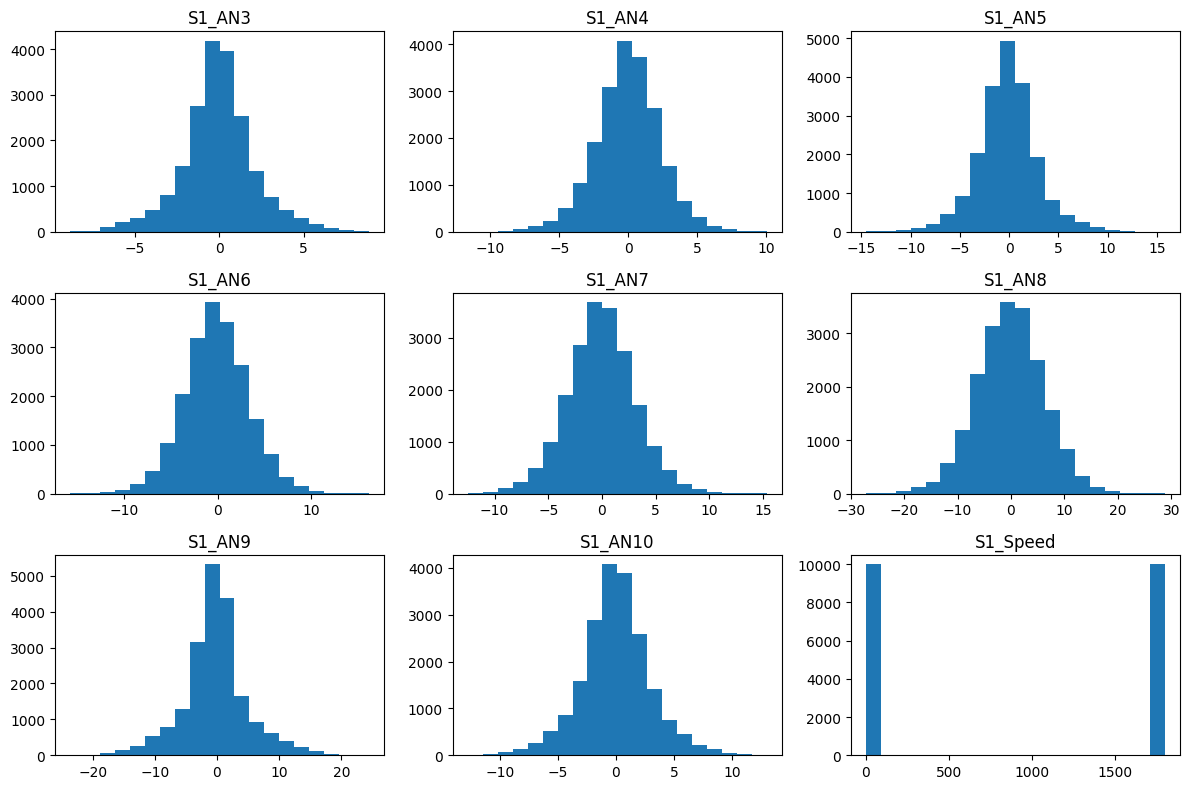

In [22]:
dependent_var =  'State'  # <-- Replace this with your actual target column
skip_var = 'index'

# Select only independent (feature) columns
feature_cols = dfGbxData.columns[dfGbxData.columns != dependent_var]
feature_cols = feature_cols[feature_cols != skip_var]

# Normalise the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(dfGbxData)

# Plot histograms for feature columns
dfGbxData[feature_cols].hist(bins=20, figsize=(12, 8), grid=False)
plt.tight_layout()
plt.show()

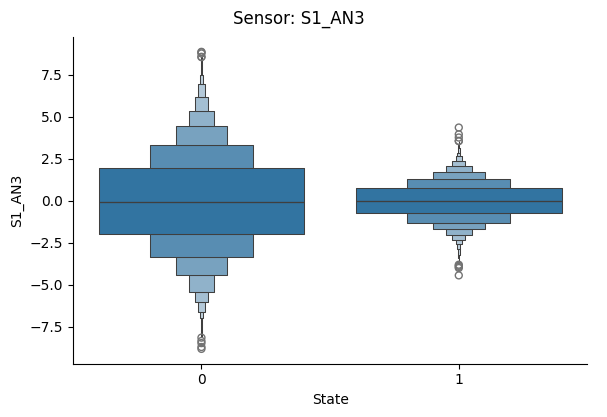

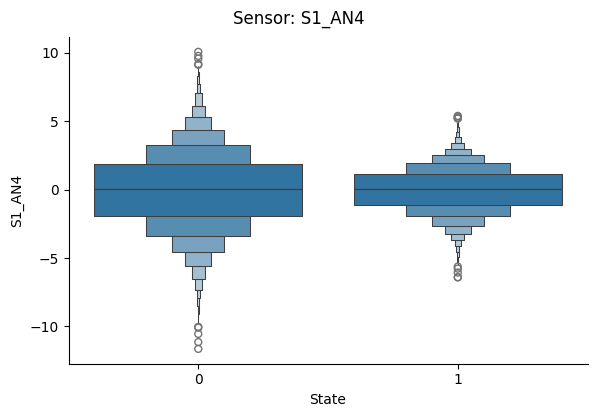

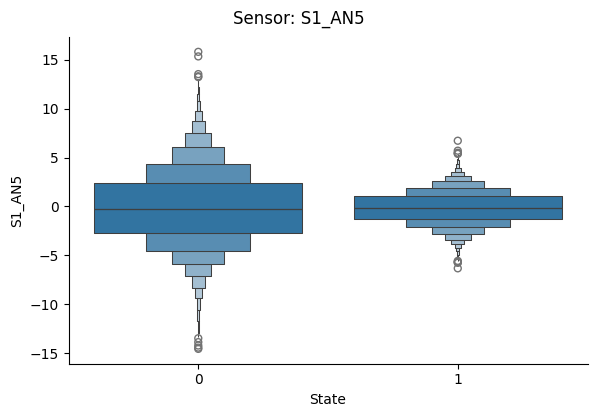

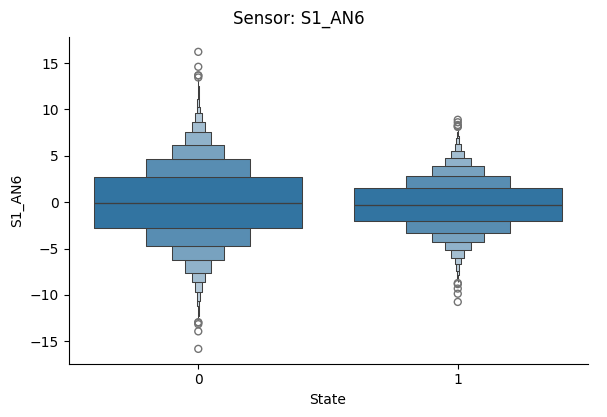

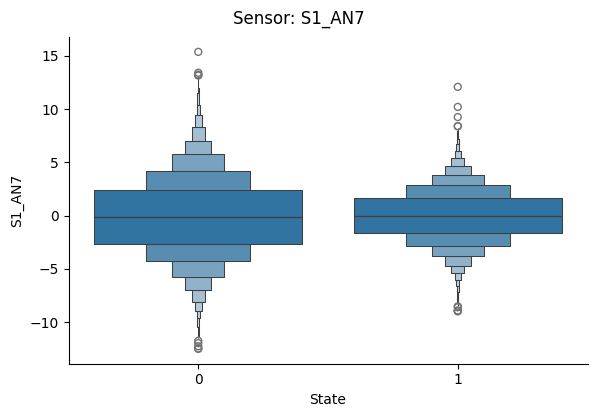

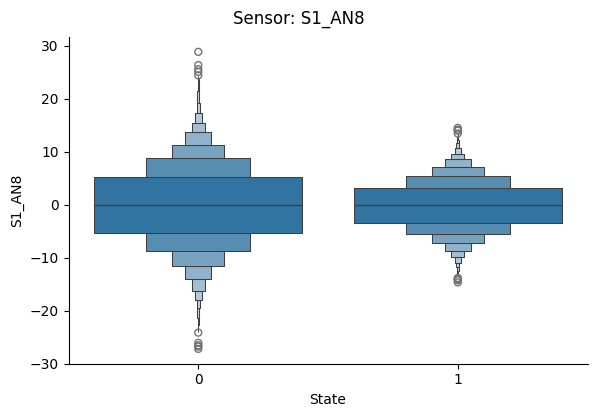

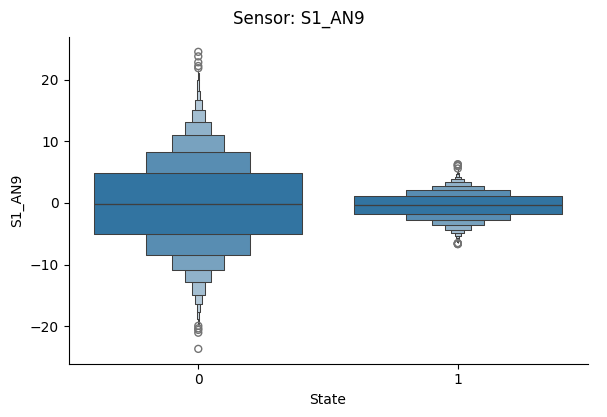

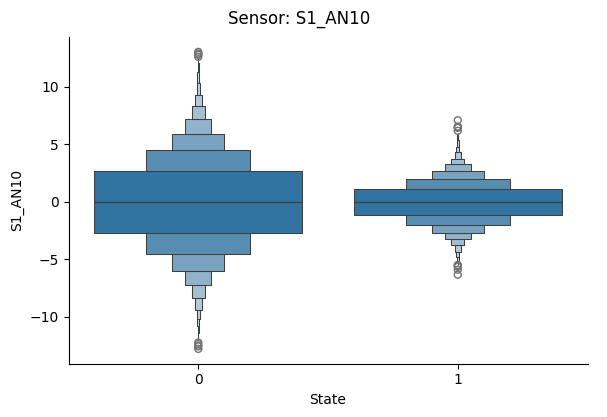

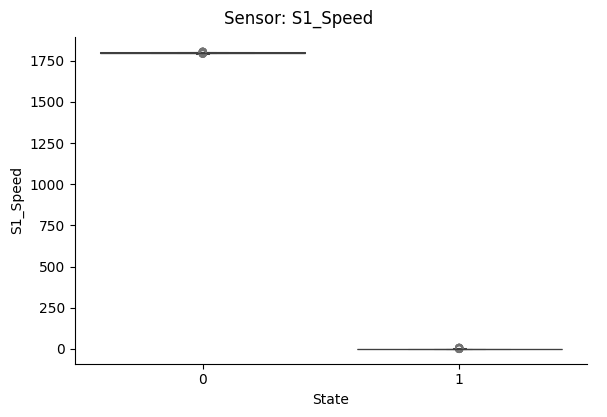

In [19]:
feature_cols = dfGbxData.columns[1:-1]  # all columns except first and last one (assuming it's 'State')

for sensor in feature_cols:
    sns.catplot(
        data=dfGbxData,
        x='State', y=sensor,
        kind='boxen',
        height=4, aspect=1.5
    ).fig.suptitle(f'Sensor: {sensor}', y=1.03)

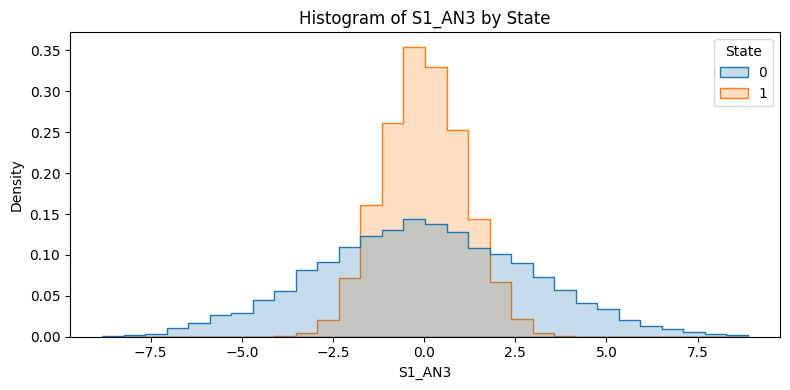

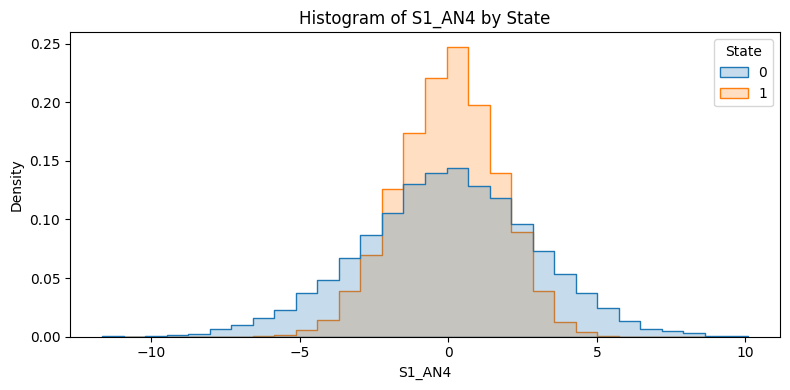

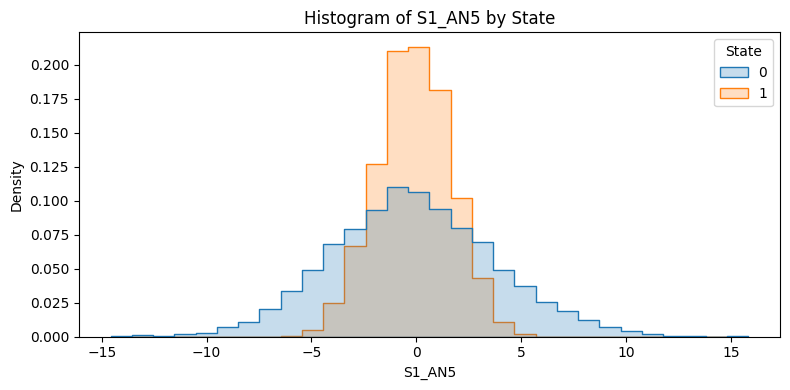

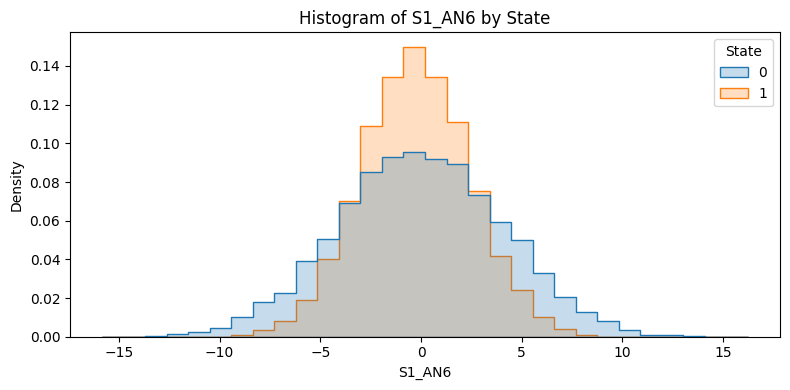

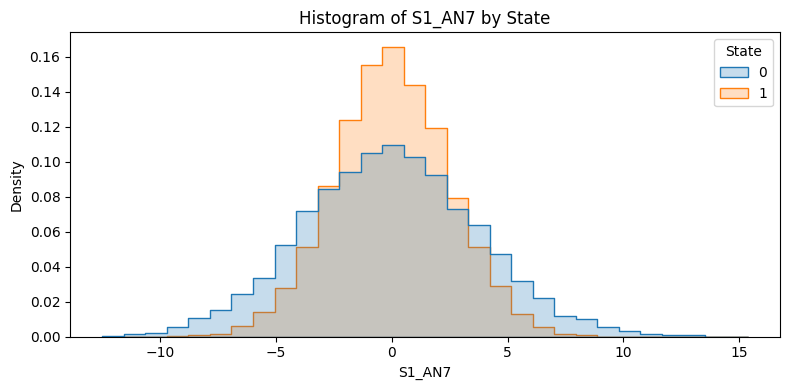

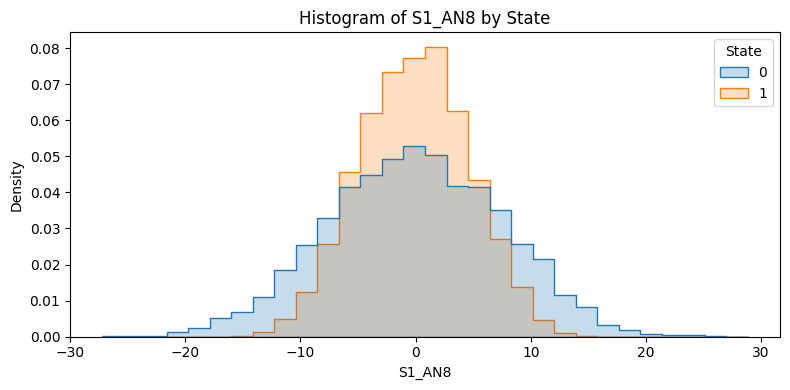

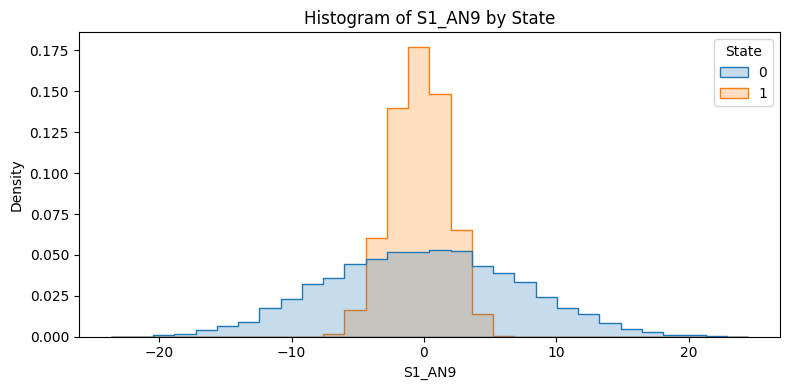

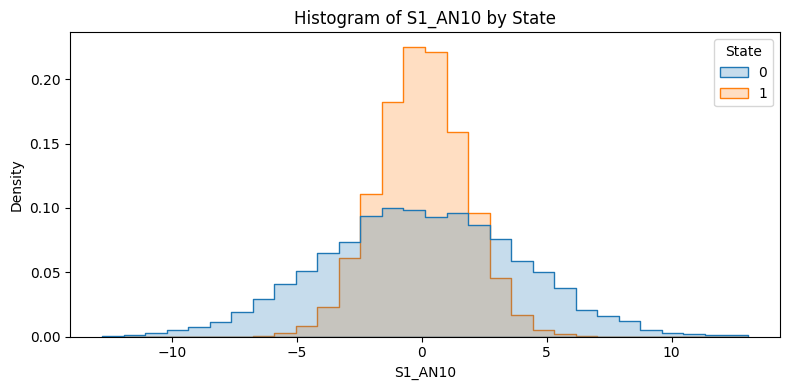

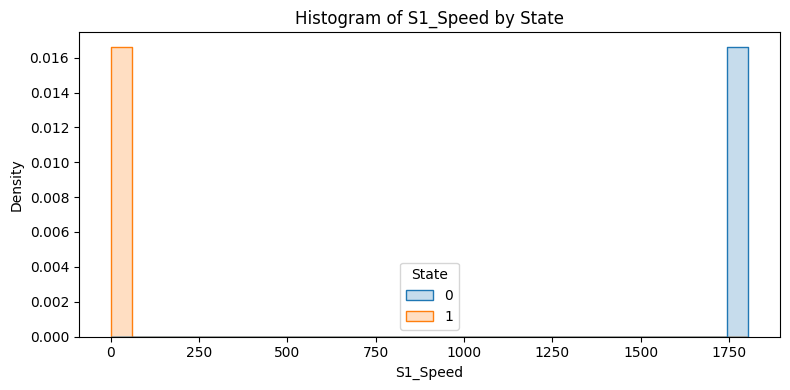

In [21]:
n = len(feature_cols)
for col in feature_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=dfGbxData, x=col, hue='State', bins=30, kde=False, element='step', stat='density', common_norm=False)
    plt.title(f'Histogram of {col} by State')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

Use t-test or ANOVA if Target is Binary or Multiclass

In [127]:
from scipy.stats import f_oneway
features_with_no_dependancy = []
for i in range(0, len(feature_cols)):
    # Group the numerical variable by target class
    groups = [group[feature_cols[i]].values for State, group in dfGbxData.groupby('State')]
    
    # Run ANOVA
    f_stat, p_value = f_oneway(*groups)  
    
    
    # Visualize
    #sns.boxplot(x='State', y='S1_Speed', data=dfGbxData)
    #plt.title('Speed vs State correlation')
    #plt.show()
    
    if p_value < 0.05:
        print("Significant dependency between " + feature_cols[i] + " and State.")
    else:
        print("No significant dependency between " + feature_cols[i] + " and State.")
        features_with_no_dependancy.append(feature_cols[i])
    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_value:.4f}")


No significant dependency between S1_AN3 and State.
F-statistic: 0.3797
p-value: 0.5377
No significant dependency between S1_AN4 and State.
F-statistic: 0.9717
p-value: 0.3243
No significant dependency between S1_AN5 and State.
F-statistic: 0.2013
p-value: 0.6537
Significant dependency between S1_AN6 and State.
F-statistic: 19.7897
p-value: 0.0000
No significant dependency between S1_AN7 and State.
F-statistic: 2.2990
p-value: 0.1295
No significant dependency between S1_AN8 and State.
F-statistic: 0.0946
p-value: 0.7584
Significant dependency between S1_AN9 and State.
F-statistic: 15.2783
p-value: 0.0001
No significant dependency between S1_AN10 and State.
F-statistic: 0.1320
p-value: 0.7164
Significant dependency between S1_Speed and State.
F-statistic: 3406840930.0153
p-value: 0.0000


In [128]:
print(features_with_no_dependancy)

['S1_AN3', 'S1_AN4', 'S1_AN5', 'S1_AN7', 'S1_AN8', 'S1_AN10']


In [124]:
xModel = dfGbxData.drop(columns=['index', 'State'], axis=1, errors='ignore')
yModel = dfGbxData['State']
print(xModel.shape)
print(yModel.shape)

(20000, 9)
(20000,)


In [123]:
dfGbxData.describe()

,index,S1_AN3,S1_AN4,S1_AN5,S1_AN6,S1_AN7,S1_AN8,S1_AN9,S1_AN10,S1_Speed,State
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,4999.500000,-0.012685,-0.010178,-0.115570,-0.143529,-0.031917,-0.067409,-0.234698,-0.011029,899.911002,0.500000
std,2886.823503,2.176021,2.368158,3.027779,3.440920,3.178270,6.274276,5.238612,3.027946,899.847576,0.500013
min,0.000000,-8.827432,-11.638441,-14.575265,-15.825101,-12.491863,-27.203736,-23.666003,-12.793893,-0.431124,0.000000
25%,2499.750000,-1.170979,-1.424945,-1.794260,-2.389485,-2.046820,-4.184922,-2.697771,-1.700901,0.000612,0.000000
50%,4999.500000,-0.030138,0.042856,-0.161669,-0.200160,-0.056857,-0.052283,-0.292189,-0.004516,899.726146,0.500000
75%,7499.250000,1.116780,1.462306,1.521015,2.074245,1.971457,4.030634,2.116553,1.683157,1800.080421,1.000000
max,9999.000000,8.875255,10.075979,15.827827,16.217307,15.363497,28.839201,24.487893,13.047979,1804.617940,1.000000


In [120]:
xModel.describe()

,S1_AN3,S1_AN4,S1_AN5,S1_AN6,S1_AN7,S1_AN8,S1_AN9,S1_AN10,S1_Speed
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-0.012685,-0.010178,-0.115570,-0.143529,-0.031917,-0.067409,-0.234698,-0.011029,899.911002
std,2.176021,2.368158,3.027779,3.440920,3.178270,6.274276,5.238612,3.027946,899.847576
min,-8.827432,-11.638441,-14.575265,-15.825101,-12.491863,-27.203736,-23.666003,-12.793893,-0.431124
25%,-1.170979,-1.424945,-1.794260,-2.389485,-2.046820,-4.184922,-2.697771,-1.700901,0.000612
50%,-0.030138,0.042856,-0.161669,-0.200160,-0.056857,-0.052283,-0.292189,-0.004516,899.726146
75%,1.116780,1.462306,1.521015,2.074245,1.971457,4.030634,2.116553,1.683157,1800.080421
max,8.875255,10.075979,15.827827,16.217307,15.363497,28.839201,24.487893,13.047979,1804.617940


In [125]:
yModel.describe()

count    20000.000000
mean         0.500000
std          0.500013
min          0.000000
25%          0.000000
50%          0.500000
75%          1.000000
max          1.000000
Name: State, dtype: float64

In [132]:
# Train Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    xModel, yModel,
    train_size=0.8,
    random_state=42,
    stratify=yModel
)

In [133]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import AdaBoostClassifier

In [134]:
# Standarise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# initialize the adaBoost classifier with a base estimator
baseEstimator = RandomForestClassifier(n_estimators=100, random_state=42)
adaboost_model = AdaBoostClassifier(estimator=baseEstimator,n_estimators=50,learning_rate=1.0,random_state=42)

# Train
adaboost_model.fit(X_train_scaled, y_train)

# Predict
y_pred = adaboost_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)


c:\users\anand.khare\documents\learnings\venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2000
           1       1.00      1.00      1.00      2000

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [135]:
from tpot import TPOTClassifier
tpot_td = TPOTClassifier(generations=5, random_state=42, max_time_mins=2)
tpot_td.fit(X_train, y_train)
print(f'Best accuracy score: {tpot_td.score(X_test, y_test):0.3%}')

Version 0.12.2 of tpot is outdated. Version 1.1.0 was released Thursday July 03, 2025.


Best accuracy score: 100.000%


In [136]:
pd.Series([
    model.split('(')[0]
    for model
    in tpot_td.evaluated_individuals_.keys()
]).value_counts()

ExtraTreesClassifier          9
BernoulliNB                   7
GradientBoostingClassifier    7
LinearSVC                     6
RandomForestClassifier        6
SGDClassifier                 6
DecisionTreeClassifier        6
XGBClassifier                 6
KNeighborsClassifier          5
MLPClassifier                 4
GaussianNB                    2
LogisticRegression            2
MultinomialNB                 1
Name: count, dtype: int64

In [129]:
print(features_with_no_dependancy)

['S1_AN3', 'S1_AN4', 'S1_AN5', 'S1_AN7', 'S1_AN8', 'S1_AN10']


Gearbox state has no dependancy on above features/sensors. Lets drop them and see if training accuracy improves.

In [130]:
xModel = dfGbxData.drop(columns=features_with_no_dependancy, axis=1, errors='ignore')
yModel = dfGbxData['State']
print(xModel.shape)
print(yModel.shape)

(20000, 5)
(20000,)


In [137]:
X_train, X_test, y_train, y_test = train_test_split(
    xModel, yModel,
    train_size=0.8,
    random_state=42,
    stratify=yModel
)

In [138]:
# Standarise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# initialize the adaBoost classifier with a base estimator
baseEstimator = RandomForestClassifier(n_estimators=100, random_state=42)
adaboost_model = AdaBoostClassifier(estimator=baseEstimator,n_estimators=50,learning_rate=1.0,random_state=42)

# Train
adaboost_model.fit(X_train_scaled, y_train)

# Predict
y_pred = adaboost_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)


c:\users\anand.khare\documents\learnings\venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2000
           1       1.00      1.00      1.00      2000

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [139]:
from tpot import TPOTClassifier
tpot_td = TPOTClassifier(generations=5, random_state=42, max_time_mins=2)
tpot_td.fit(X_train, y_train)
print(f'Best accuracy score: {tpot_td.score(X_test, y_test):0.3%}')

Version 0.12.2 of tpot is outdated. Version 1.1.0 was released Thursday July 03, 2025.


Best accuracy score: 100.000%


In [140]:
pd.Series([
    model.split('(')[0]
    for model
    in tpot_td.evaluated_individuals_.keys()
]).value_counts()

ExtraTreesClassifier          9
BernoulliNB                   7
GradientBoostingClassifier    7
LinearSVC                     6
RandomForestClassifier        6
SGDClassifier                 6
DecisionTreeClassifier        6
XGBClassifier                 6
KNeighborsClassifier          5
MLPClassifier                 4
GaussianNB                    2
LogisticRegression            2
MultinomialNB                 1
Name: count, dtype: int64

In [17]:
dfGbxData.to_csv('train_data.csv', index=False)